In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
dataA = pd.read_csv("A1_dataA.tsv", sep="\t") 
dataB = pd.read_csv("A1_dataB.tsv", sep="\t")
#Check data
print(dataA.head())
print(dataB.head())


         X1        X2        X3        X4        X5  class
0  0.941443  0.739137  0.789515  0.783686  0.165450      1
1  0.903789  0.774421  1.807503 -1.403254  0.531660      1
2  0.988921  0.763048  1.608549  0.354220  0.979188      1
3  0.945123  1.167735  1.140172 -0.749005  0.171429      0
4  0.912966  1.035160  0.548504  0.499823  0.084890      0
         X1        X2        X3        X4        X5  class
0  0.509022  0.977143  1.807426 -0.456832  1.114991      1
1  0.431006  0.340303 -0.991420 -0.533280  0.033497      1
2  0.601544  1.627891 -0.144424  0.070053  0.485216      1
3 -0.346139  0.435936  1.240060  0.286332  0.475602      1
4  1.669372  0.390462  1.225110 -0.809030  0.088785      1


In [127]:
dataA_nonscaled=dataA.copy()
#Scale Data
scaler = StandardScaler()
dataA[["X1","X2","X3","X4","X5"]]= scaler.fit_transform(dataA[["X1","X2","X3","X4","X5"]])
dataA

,X1,X2,X3,X4,X5,class
0,-0.044245,-0.418993,0.167519,1.050053,-0.390117,1
1,-1.290281,-0.318720,1.350108,-2.240164,0.522098,1
2,1.526875,-0.351041,1.118985,0.403928,1.636870,1
3,0.077526,0.799023,0.574876,-1.255857,-0.375223,0
4,-0.986605,0.422262,-0.112460,0.622986,-0.590786,0
...,...,...,...,...,...,...
95,-1.185032,-0.824963,1.745305,0.975435,1.056538,0
96,2.472764,0.999420,-0.396257,-1.209475,-0.629725,0
97,0.423208,1.378425,-0.773909,0.123818,1.781680,1
98,-0.955933,0.531518,0.881046,0.767355,-1.293381,0


In [128]:

#Melt for seaborn
dataA_graph = dataA.melt(
    id_vars=dataA.columns[-1],
    value_vars=dataA.columns[:-1],
    var_name="Feature",
    value_name="Value"
)


In [129]:
#We have two classes
# pd.set_option('display.max_rows',None)
# dataA[dataA["class"]==1]

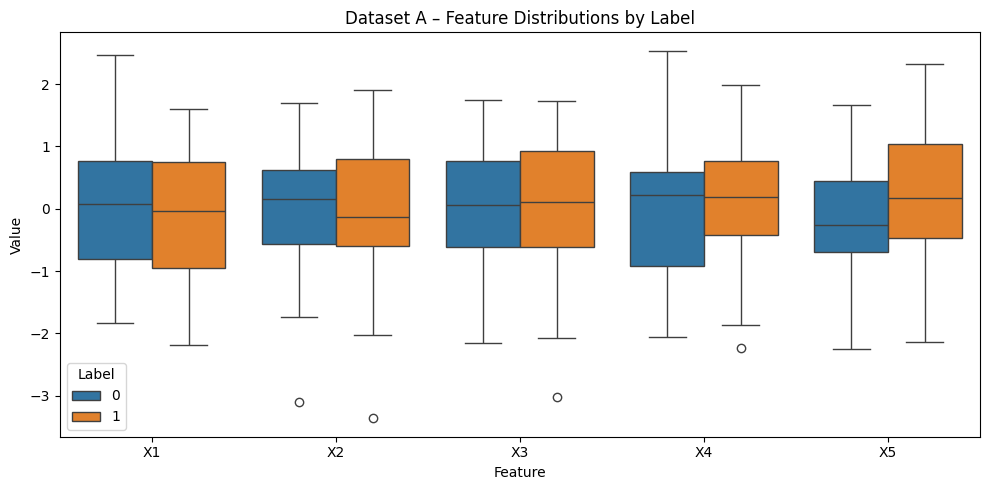

In [130]:
#Boxplot

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Feature",
    y="Value",
    hue=dataA.columns[-1],
    data=dataA_graph
)
plt.title("Dataset A – Feature Distributions by Label")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

Dataset A contains some informative features, suggesting the presence of meaningful signal that could be exploited by a machine learning model.

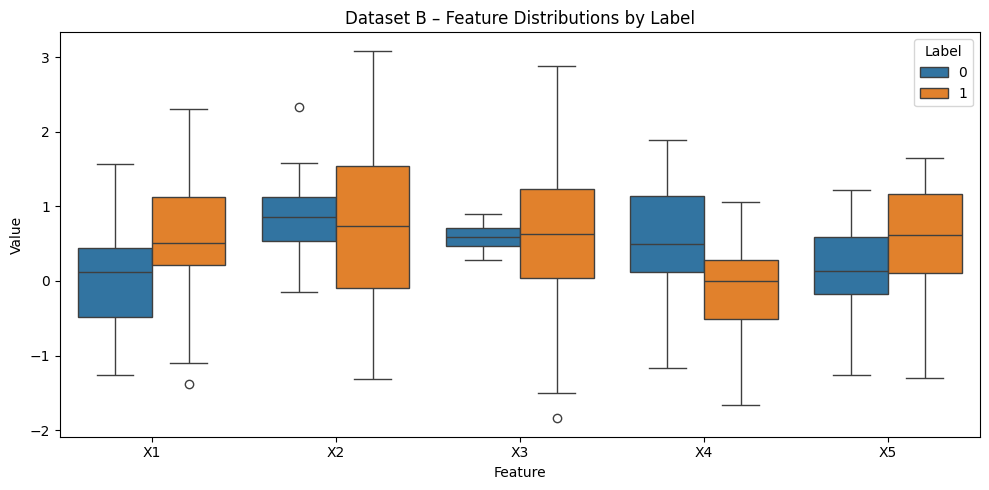

In [131]:
dataB = pd.read_csv("A1_dataB.tsv", sep="\t")

dataB_graph = dataB.melt(
    id_vars=dataB.columns[-1],
    value_vars=dataB.columns[:-1],
    var_name="Feature",
    value_name="Value"
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    x="Feature",
    y="Value",
    hue=dataB.columns[-1],
    data=dataB_graph
)

plt.title("Dataset B – Feature Distributions by Label")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.legend(title="Label")
plt.tight_layout()
plt.show()


In [132]:
dataA.index

RangeIndex(start=0, stop=100, step=1)

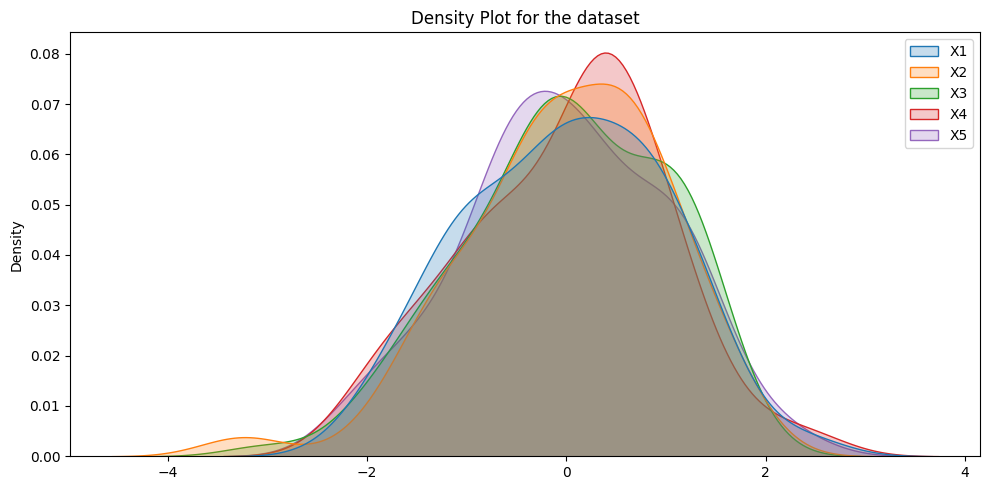

In [133]:
#Density Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=pd.DataFrame(dataA[["X1","X2","X3","X4","X5"]]),
    fill=True,
    legend=True,
)
plt.title("Density Plot for the dataset")
plt.tight_layout()
plt.show()

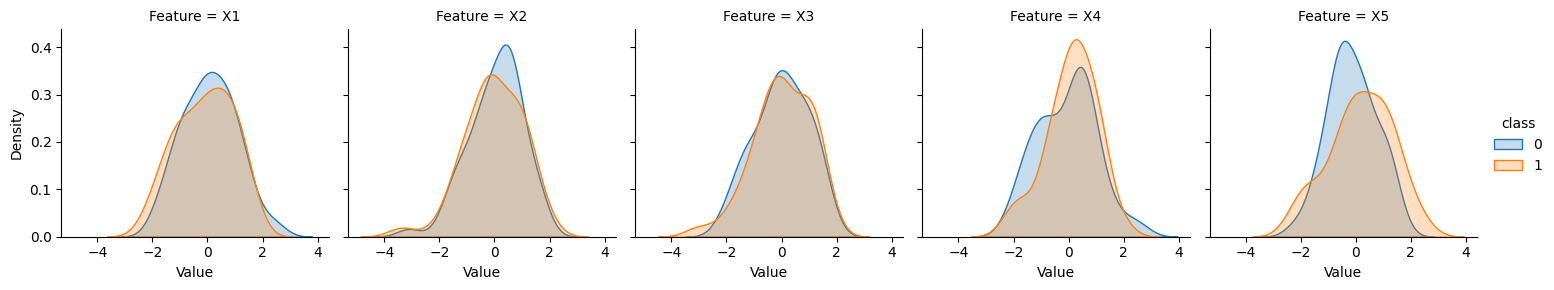

In [134]:
density_plot_with_class=sns.FacetGrid(dataA_graph, col="Feature", hue="class", col_wrap=5, sharex=True)
density_plot_with_class.map(sns.kdeplot, "Value", fill=True)
density_plot_with_class.add_legend()
plt.show()

Dataset B shows substantial overlap between class labels across all features, indicating little to no discriminative signal for effective machine learning.

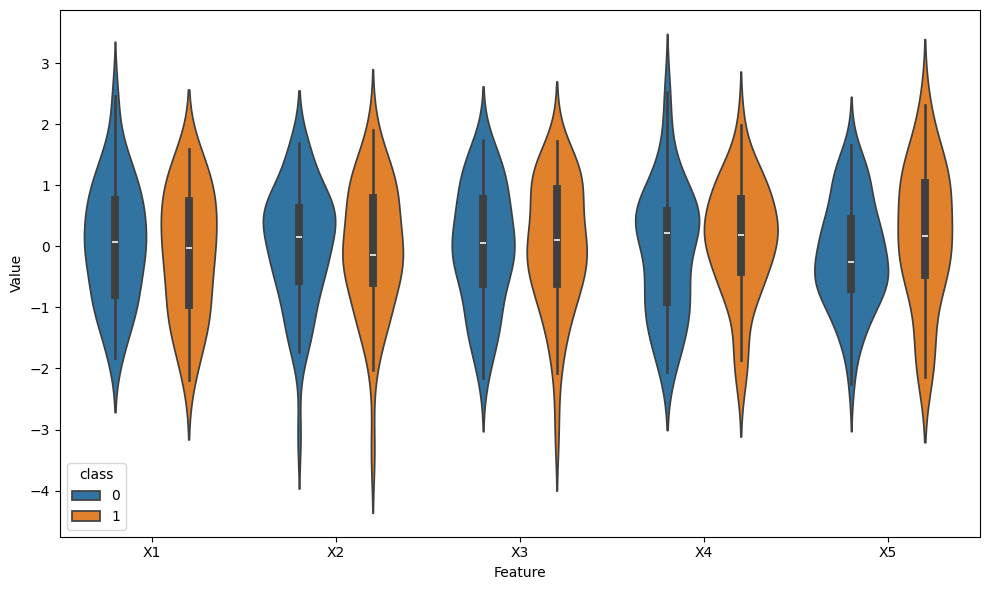

In [135]:
#Violin plot
plt.figure(figsize=(10, 6))
violinplt=sns.violinplot(data=dataA_graph, x="Feature",y="Value",hue="class",legend=True)
plt.tight_layout()
plt.show()

In [ ]:
X=dataA[["X1","X2","X3","X4","X5"]]
Y=dataA["class"]
knn=KNeighborsClassifier()
def run_skf_knn(knn,X,Y):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    cv_results_accuracy = cross_val_score(knn, X, Y, cv=skf, scoring='accuracy')
    cv_results_average_precision = cross_val_score(knn, X, Y, cv=skf, scoring='average_precision')
    cv_results_f1 = cross_val_score(knn, X, Y, cv=skf, scoring='f1')
    cv_results_precision = cross_val_score(knn, X, Y, cv=skf, scoring='precision')
    print(f"Average Precesion: {cv_results_average_precision.mean()}")
    print(f"Accuracy: {cv_results_accuracy.mean():.4f}")
    print(f"F1-score: {cv_results_f1.mean():.4f}")
    print(f"Precesion: {cv_results_precision:.4f}")
    return skf

skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.5324206349206348
Accuracy: 0.5900
F1-score: 0.4302
Precesion: [0.42857143 1.         0.75       0.6        0.4        0.5
 0.5        0.         0.33333333 0.5       ]


/Users/arya/Desktop/TERM8/COMP3202/Assignment 1/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


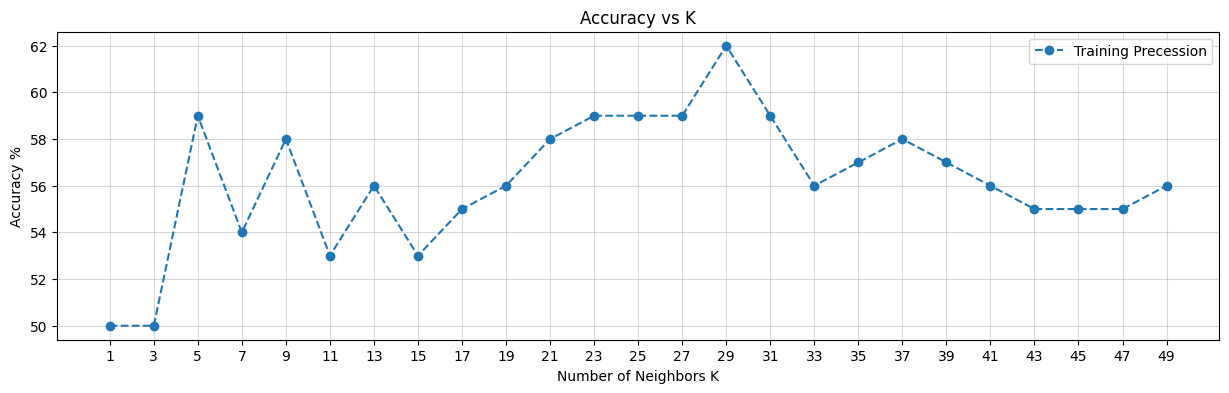

In [137]:

k_values = range(1, 51, 2)
model_accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    #testing accuracies
    model_score= cross_val_score(model,X,Y,cv=skf,scoring="accuracy")
    model_accuracies.append(model_score.mean()*100)


plt.figure(figsize=(15,4))
plt.plot(k_values, model_accuracies, label='Training Precession', marker='o', linestyle='--')

plt.title('Accuracy vs K')
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy %')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [138]:
#Confirms our choice of K =5
skf=run_skf_knn(KNeighborsClassifier(n_neighbors=5),X,Y)


Average Precesion: 0.5324206349206348
Accuracy: 0.5900
F1-score: 0.4302
Precesion: [0.42857143 1.         0.75       0.6        0.4        0.5
 0.5        0.         0.33333333 0.5       ]


/Users/arya/Desktop/TERM8/COMP3202/Assignment 1/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [139]:
#Now lets test our hypothesis that only two of the 5 features are useful
X=dataA[["X4","X5"]]
Y=dataA["class"]
knn=KNeighborsClassifier()
skf=run_skf_knn(knn,X,Y)

Average Precesion: 0.5873095238095237
Accuracy: 0.5700
F1-score: 0.3996
Precesion: [0.66666667 1.         0.25       0.66666667 1.         0.5
 0.5        0.33333333 0.25       0.5       ]


As we can see the accuracy only goes down by 0.02 that is 2% confirming our hypothesis that the other features are not as useful. 
Now that KNN is 2D we can also plot the decession boundaries.